# Assignment 4: Sound Event Localization and Detection (SELD)


CS-GY 9223: Machine Listening

**Due:** Thursday, April 23rd

**Read through the text, code, and comments carefully and fill-in the blanks accordingly. Code and written questions you need to fill in will be denoted with "TODO" markers.**

**For all plots, include axis labels with units of measurement when applicable. Lack of this will result in small points deductions.**

The assignment will be 10 points total, there will not be a quiz for this assignment.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
from glob import glob
import gc
from tqdm import tqdm
import matplotlib.pyplot as plt
import IPython.display as ipd

# SELD Model Overview
For this assignment, you will implement, train, and evaluate a sound event localization and detection model, based on the framework discussed in class of [DCASE 2019 Task 3](https://dcase.community/challenge2019/task-sound-event-localization-and-detection).

Your SELD model will perform both **detection** (e.g. "is a sound event class present in a given frame?") and **localization** (e.g. "where is this sound event coming from?").

Model overview:
- **Model input**: magnitude and phase information from the STFT of 4-channel First Order Ambisonics (FOA) audio
- **Multi-task model output**: per 20ms frame (e.g. 3000 frames per 1 min clip):
    - **SED output**: in the continuous range of [0,1] for each class. This will be thresholded >0.5 for class activity detection in evaluation. Overall shape here will be `(batch, T, C)` where T is frame index and C is class index.
    - **DOA output**: in the continuous range of [-1,1] for each axes of the sound class location. Overall shape here will be `(batch, T, 3C)` where x, y, and z are DOA coordinates are predicted for each class at each time frame.

The data processing, model architecture, and evaluation are detailed best in the paper released with this challenge [here](https://arxiv.org/pdf/1807.00129).


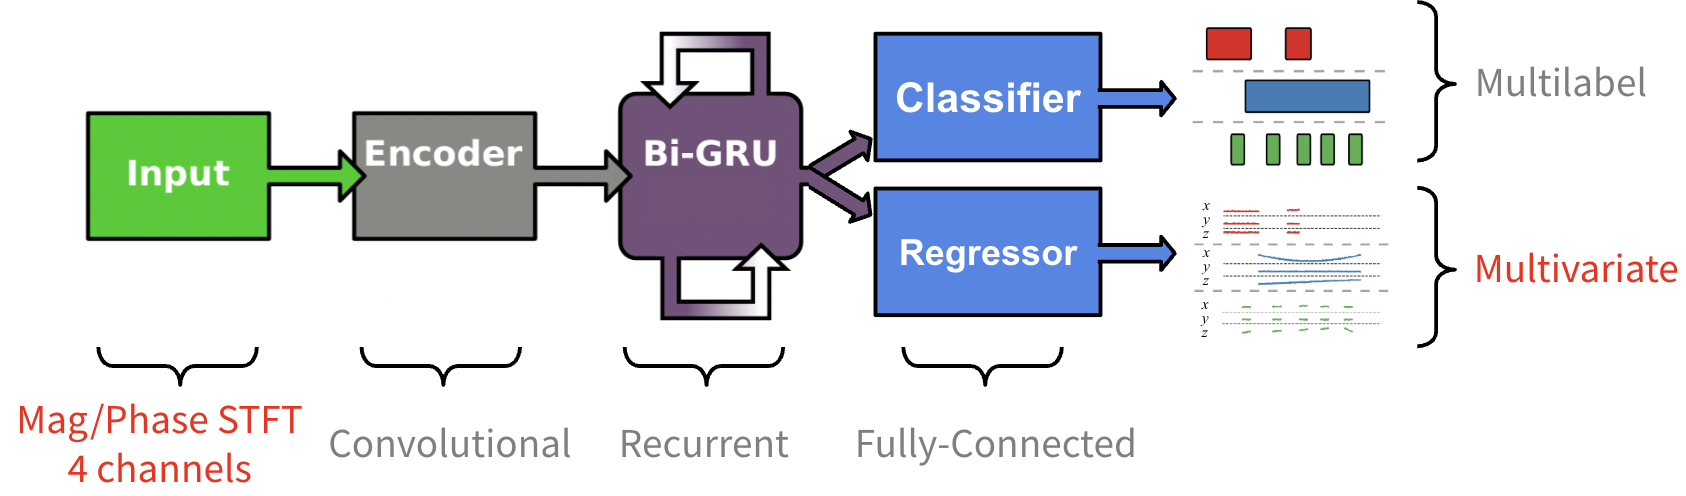



# Part 1: Data
For this assignment, we will use the DCASE 2019 Task 3 dataset with a couple specifications:
- We will be using the 4-channel FOA (first-order Ambisonics) audio, not the "MIC" format.
- We will use the **development** dataset only, which has 400 1-minute recordings at 48kHz.
- There can be simultaneous sounds from different classes, but not from the same class.
- Use folds 3 and 4 for training, fold 2 for validation, and 1 for test.
- The recordings follow the following naming convention:
`split[number]_ir[location number]_ov[number of overlapping sound events]_[recording number per split].wav`.

## Getting the data
Download the DCASE FOA development dataset from Google Drive here: https://drive.google.com/drive/folders/1lTgUcnbHKO-BL2JSRXdtpI9SxaKfiOn_?usp=sharing. This contains the metadata and ambisonics audio.

Put these zip files in your Drive, then mount your drive and unzip the files running the code below.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
!unzip "/content/drive/MyDrive/assignment4_files/metadata_dev.zip" -d "/content"

In [ ]:
!unzip "/content/drive/MyDrive/assignment4_files/foa_dev_all_compressed.zip" -d "/content"

In [ ]:
# Remove two files in train set with corrupt audio
!rm "/content/foa_dev/split4_ir0_ov2_18.wav"
!rm "/content/foa_dev/split4_ir1_ov2_32.wav"
!rm "/content/metadata_dev/split4_ir0_ov2_18.wav"
!rm "/content/metadata_dev/split4_ir1_ov2_32.wav"

## Feature extraction and data loading
### ❗Deliverables❗
1. A dataloader class that yields features and labels from the 4-channel FOA audio and metadata: (1) STFT features (2) the ground truth DOA labels, in Cartesian coordinates, and (3) the ground truth detection labels. (See below for more details).
3. Print the shapes of your input features and 2 sets of ground truth labels while running a sample batch iteration through your dataloader.
3. For `foa_dev/split1_ir0_ov1_1.wav`, (1) play the omnidirectional channel, (2) plot the spectrogram of the omnidirectional channel (3) the detection labels, and (4), for one class, the x/y/z coordinates over time. Check that these align and everything is making sense (for both a full file and a segmented file).


**Audio Features**
- Load the 4-channel FOA waveform and pad to 60-seconds to ensure we get the same total number of frames per clip.
- For each of the 4 FOA channels, get the magnitude and phase from the STFT of the audio. Use the parameters in the template dataloader below such that we get 50 frames per second (one frame per 0.02 seconds audio), e.g. 3000 frames for a 60-second clip.
- ⚠️ For training, we will not use the full 3000 timeframes at once. **At train time, select 500** (10-seconds) frames out of the 3000 at random per sample each epoch. Make sure to truncate the STFT features **and SED and DOA labels** with the same indexing! In validation, also select 500, but fix the indexing. At test time you will do inference on 6 consecutive 500-frame chunks and concatenate the predictions for your final output.⚠️
- Final feature dimension should be shape `(T x N/2 x 2K)`, where `N` is the length of your STFT window (N/2 because of positive frequencies only being used, discard 0th bin), T is the number of time frames (500), and K is the number of channels (2K due to stacking K magnitude components and K phase components).
- See below for STFT parameters recommended.

**Labels**

Each input feature matrix should have two corresponding ground truth features:
- DOA ground truth: Overall shape here will be `(batch, T, 3C)` where x, y, and z are DOA coordinate for each class at each time frame. Note that the metadata contains this position in elevation and azimuth (degrees) instead of in cartesian coordinates. We will evaluate in elevation and azimuth, but for training, use cartesian. You can convert between the two with the helper functions I've provided below.
- SED ground truth: Overall shape here will be `(batch, T, C)` where T is frame index and C is class index. This is 1 if a sound class is present in a given frame and 0 otherwise. There are 11 classes.


In [ ]:
"""
Default STFT parameters for 50 FPS at 48k sample rate:

sample_rate = 48000
window_length = 1920
hop_length = 960
nfft = 1920

For dataloading in train/val:
num_frames = 500 (also `T` in slides/notation)

Data splits (split per file specified in filename):
split2ints = {"train": {3, 4},
            "valid": {2},
            "test": {1}}

Class indexing:

cls2idx = {'clearthroat': 0,
 'cough': 1,
 'doorslam': 2,
 'drawer': 3,
 'keyboard': 4,
 'keysDrop': 5,
 'knock': 6,
 'laughter': 7,
 'pageturn': 8,
 'phone': 9,
 'speech': 10}
"""

In [9]:
# TODO : Your dataloader with processing code (can use plenty of helper functions as needed!)

class SELDDataset(Dataset):
    def __init__(self): # Customize these arguments
        """
        Args:
            TODO
        """
        # TODO : everything else in your dataloader init
        pass

    def __len__(self):
        # TODO
        pass

    def __getitem__(self, idx):
        stft_feats, doa_matrix, sed_matrix = None
        # TODO
        # Compute audio features and metadata processing
        # Work in Cartesian coordinates (x,y,z) for the model (note metadata is in az/ele degrees)
        return stft_feats, doa_matrix, sed_matrix


# Conversion helper functions:
def sph2cart(azi_deg, ele_deg, dist=1.0):
    """
    Convert azimuth/elevation in degrees to Cartesian x,y,z.
    Operates on individual scalar inputs, not a batch in this current implementation.

    Assumes:
      - azimuth: degrees
      - elevation: degrees
      - distance: radius
    """
    azi = np.deg2rad(azi_deg)
    ele = np.deg2rad(ele_deg)

    x = dist * np.cos(ele) * np.cos(azi)
    y = dist * np.cos(ele) * np.sin(azi)
    z = dist * np.sin(ele)
    return x, y, z


In [ ]:
# TODO
# Clearly label each piece of the code in the deliverables here

# Part 2: Building your SELD model
Using the architecture explained in class and pictured, design a simple SELD PyTorch model based on the baseline system from the DCASE 2019 task 3. Recall the model input and output:

- **Model input**: magnitude and phase information from the STFT of 4-channel First Order Ambisonics (FOA) audio as produced by your dataloader.
- **Multi-task model output**: per 20ms frame (e.g. 500 frames per 10-seconds):
    - **SED output**: in the continuous range of [0,1] for each class. This will be thresholded (typically at >0.5, but threshold can be tuned) for class activity detection in evaluation. Overall shape here will be `(batch, T, C)` where T is frame index and C is class index.
    - **DOA output**: in the continuous range of [-1,1] for each axes of the sound class location. Overall shape here will be `(batch, T, 3C)` where x, y, and z are Cartesian DOA coordinates are predicted for each class at each time frame.


Other notes on model architecture:
- We follow the architecture from class (Lecture 7, slides 54-55) pictured below), with a few minor modifications and adjustments to parameters:
    - `K = 4`: ambisonics (FOA) audio channels
    - `N = 1920`: STFT window size
    - `H = 960`: STFT hop size
    - `T = 500`: frames for model forward pass
    - `P = 64`: CNN filters, constant throughout
    - `MP` - TODO: Adjust your 2D max pooling dimensions such that your 3x2DCNN reaches 2 dimensions by the end, to match the slide architecture.
    - `Q = 128`: nodes in hidden dimension of biGRU
    - `R = 128`: hidden dimension of linear heads
    - `C = 11`: 11 classes

- PyTorch GRU defaults to combining bidirectional GRU output via concatenation, but the original baseline model implementation actually multiplies these outputs (will change dimensionality of input to linear heads). You can experiment with either.
- Although it is not typically preferable to use a linear spectrogram with a 2D CNN architecture as discussed in class, we do so here to maintain the phase information as part of the input features.


### ❗Deliverables❗
1. Model architecture class
2. Print the architecture and number of parameters of your model
3. Dummy forward pass of your model verifying that shapes align and the forward pass is working


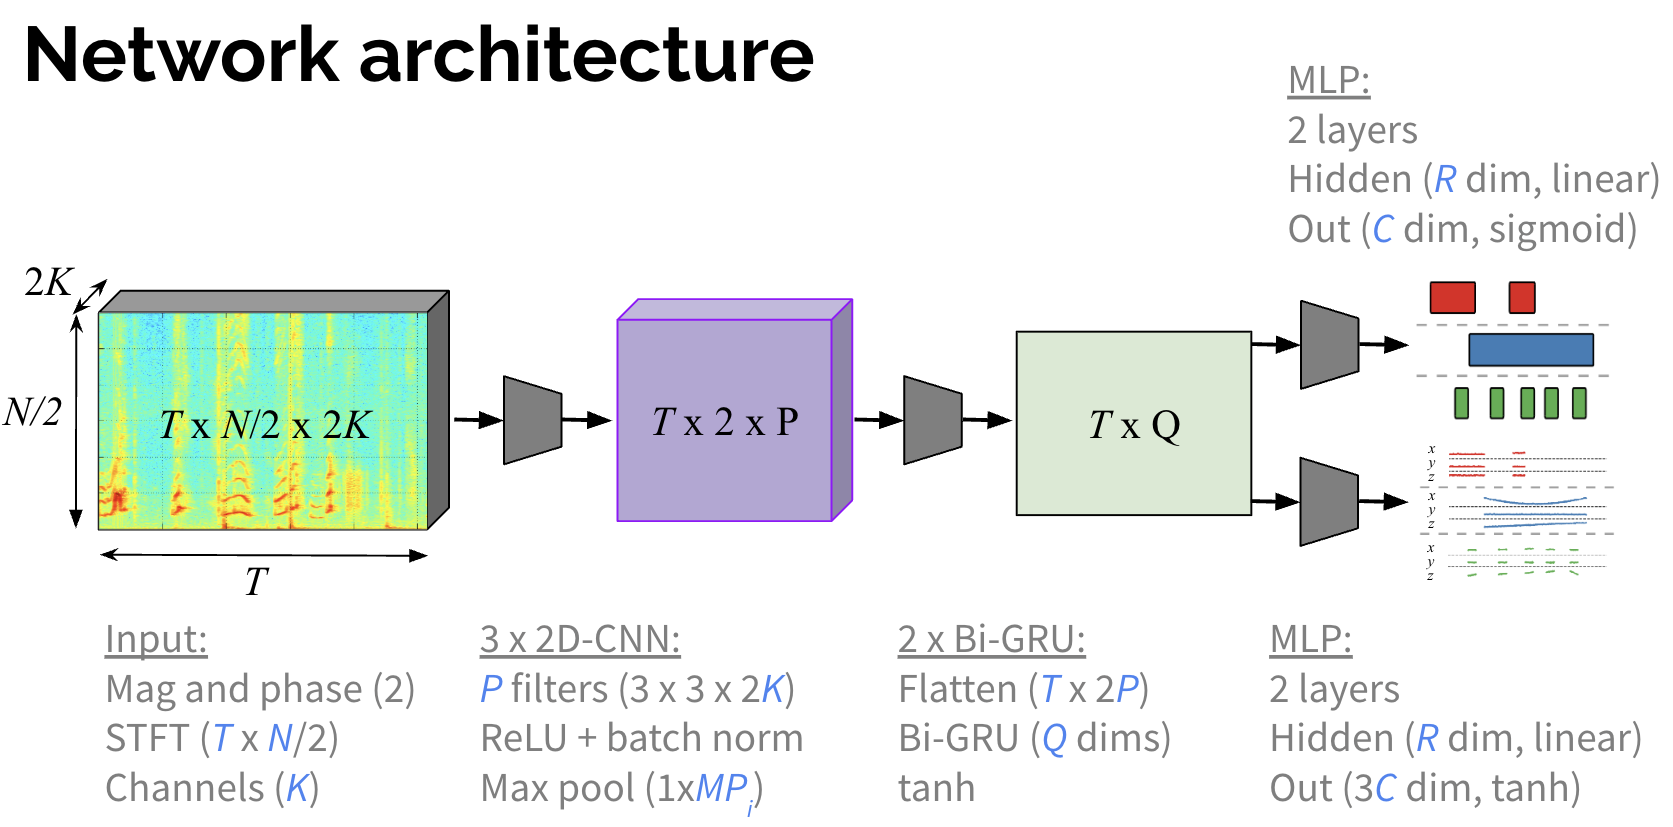

In [ ]:
# TODO : Build your model!

class SELDModel(nn.Module):
    def __init__(self, input_channels, hidden_size, dropout_rate, num_classes=11):
        """
        SELD multi‑task model:
          – 3×2D‑CNN blocks → Bi‑GRU → two MLP heads (SED & DOA)
        Args:
          input_channels: 2K (mag + phase channels; here 4‑channel FOA ⇒ 8)
          freq_dim: number of frequency channels we are expecting
          dropout_rate: dropout rate used throughout
          hidden_size:  Q (GRU hidden dim) and R (MLP hidden dim)
          num_classes:   C (number of event classes)
        """
        super().__init__()
        pass

    def forward(self, x):
        """
        Args:
            x input tensor of shape (batch_size, time, freq, channels)
              where channels = 2 × number of FOA channels (mag + phase)
        Returns:
            sed_output: Tensor of shape (batch_size, time, num_classes)
            doa_output: Tensor of shape (batch_size, time, 3 × num_classes)
        """
        pass


In [ ]:
# TODO
# Print the model architecture and number of parameters, and validate a dummy forward pass

## Training your model
Train and validate your model. Use sample code from the previous assignment for a template on training and validation scripts.

**Tips:**
- For the **loss** function, follow the loss explained in class (pictured). I recommend starting with equal weighting and tuning from there. The proposed optimal weighting params were $Β = 50*\alpha$, but tune this yourself!
- Train for at least 20 epochs. Note that on the Colab L4 GPU with batch size 2 (for out of memory issues), one training+validation loop was taking ~2 minutes for me.
- I recommend starting by ensuring you can overfit to a few training samples (e.g., loss is approaching 0) before scaling up your training. For overfitting experiments be sure to remove the random chunk sampling from your data loading.
- Start with dropout = 0 and tune from there.
- You may need to tune the learning rate, I found $1e-3$ to be effective with a batch size of 2.
- I recommend using early stopping based on validation loss plateau. Make sure to save your best model based on validation loss during training.
- You may also want to incorporate metric tracking into your training and validation code (beyond tracking only the loss). The metric code is in the evaluation section below.


### ❗Deliverables❗
1. Training and validation code
2. Plot the training and validation total loss curves (monitor this during training!)
3. Plot the training and validation loss curves broken down by the weighted SED and SEL components.
4. Save the best model based on validation loss (locally), you will need it for evaluation below.


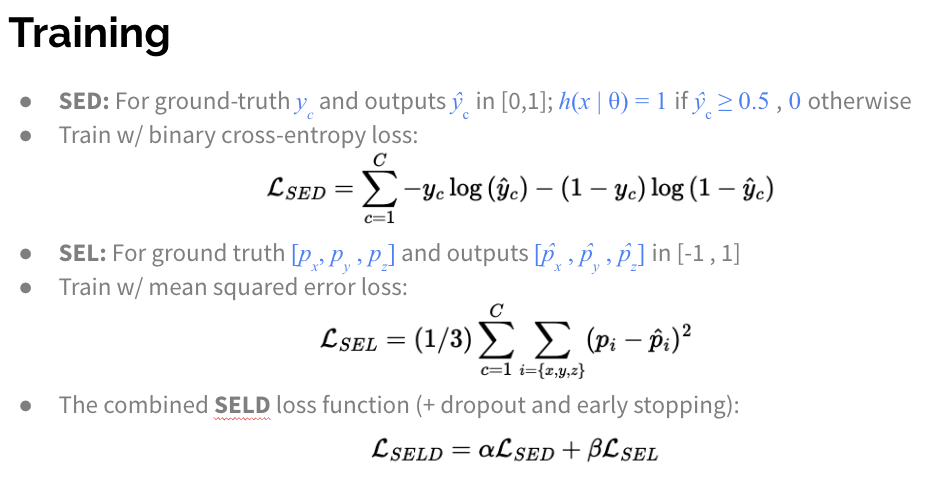

In [ ]:
# TODO : All training and validation code

In [ ]:
# If you are getting OOM run these lines to clear
import gc
gc.collect()
torch.cuda.empty_cache()

# Part 3.1: Evaluation - Qualitative
To get a better understanding of the model output versus ground truth before we get into metrics we will create some visualizations:

⚠️ Remember that your model is trained on 500-frame chunks, and for evaluation we want to get predictions for the entire 3000-frame clip. Perform inference on 6 x 500-frame consecutive chunks to get the final model output.

### ❗Deliverables❗
For the test set file `split1_ir0_ov1_8.wav`:
1. Plot the audio spectrogram of the omnidirectional channel of the audio
2. Plot the ground truth SED labels (across classes, over time), similar to figure diagram above) alongside the predicted SED labels.
3. For the `phone` and `keyboard` classes, plot the ground truth X/Y/Z DOA coordinates alongside the predicted DOA coordinates (over time).
4. **Written response**: compare the performance for the `phone` class versus the `keyboard` class for your sample clip, qualitatively. Do the classes appear to perform similarly? What about the nature of the audio in these classes may lead to this performance?


In [ ]:
# TODO: The deliverables above

**TODO - Written response**
1. Compare the performance for the `phone` class versus the `keyboard` class for your sample clip, qualitatively. Do the classes appear to perform similarly? What about the nature of the audio in these classes may lead to this performance?

YOUR ANSWER

# Part 3.2: Evaluation - Quantitative
We will focus on 2 metrics for quantitative evaluation, which we design as slight simplification of the original DCASE metrics. The metric code is provided for you. The metrics we will use are:
- For detection: **F1-score** pooled over 1-second windows. This is a relaxed version of frame by frame F1 score. Here we count a true positive as true "if there is any presence of the ground truth class within 50 frames (1 second) of the predicted SED output". An F1-score here of 60-80% is promising!
- For localization: **Localization Error**, macro-averaged over classes. Computes the angular error between ground truth and predicted DOA, per class. Localization error of 30-50 degrees is a good target to aim for (lower is better).

⚠️ Again, remember that your model is trained on 500-frame chunks, and for evaluation we want to get predictions for the entire 3000-frame clip. Perform inference on 6 x 500-frame consecutive chunks to get the final model output.

⚠️ You may need to experiment with varying your threshold (typically defaults at 0.5) for binarizing your SED predicted probabilities. Due to the sparsity of the data these models can tend to underpredict and lean towards 0s, so you may need to go lower, though smaller is not always better (can run an evaluation sweep varying this parameter).


### ❗Deliverables❗
#### Part 1: Metrics for our example above
1. Load your best performing model in terms of validation loss.
2. Use the provided metrics to evaluate the file from the qualitative analysis (`split1_ir0_ov1_8.wav`). Print the results.
3. **2-part written response**: Compare the metrics for this file to your qualitative analysis and answer these two questions:
    - (1) Does the F1-score seem to reflect what you saw qualitatively? Briefly explain your observations.
    - (2) Compare the localization error of the `phone` and `keyboard` classes (the method provides per-class results) with what you observed in the plots above. Briefly explain your observations.


#### Part 2: Overall metrics
1. Load your best performing model in terms of validation loss.
2. Run the provided metrics code  file of your test data split. Print the overall results, averaged across files.
3. **2-part written response**:
    - (1) Compare your overall results to the suggested "good" ranges for the metrics above. Are you within this range? If not, briefly explain your hypothesis for what may be going wrong.
    - (2) As a final wrap-up, comment briefly on one challenge you faced in training this model (outside of e.g., compute resources/time working on it). An example could be your strategy for tuning a specific hyperparameter and how you iterated on this.




In [ ]:
# [PROVIDED FOR YOU] Metric helper functions
def reshape_3Dto2D(A):
    return A.reshape(A.shape[0] * A.shape[1], A.shape[2])

def f1_overall_framewise(pred_sed, gt_sed, eps=1e-8):
    """
    Helper for `f1_overall_1sec` method.

    pred_sed: predicted SED (binarized) (num_seconds, num_classes)
    gt_sed: ground truth SED (binary) (num_seconds, num_classes)

    """

    if len(O.shape) == 3:
        pred_sed, gt_sed = reshape_3Dto2D(pred_sed), reshape_3Dto2D(gt_sed)
    TP = ((2 * gt_sed - pred_sed) == 1).sum()
    Nref, Nsys = gt_sed.sum(), pred_sed.sum()

    prec = float(TP) / float(Nsys + eps)
    recall = float(TP) / float(Nref + eps)
    f1_score = 2 * prec * recall / (prec + recall + eps)
    return f1_score

def f1_overall_1sec(pred_sed, gt_sed, block_size, threshold=0.5):
    """
    For each 1 second block, pool the predictions/ground truths and just check
    for alignment over that block, instead of at the indiivudal frame level.

    pred_sed: predicted SED (pre-threshold), (num_frames, num_classes)
    gt_sed: ground truth SED (binary), (num_frames, num_classes)
    block_size: number of frames for 1-sec block.
    threshold: threshold to binarize SED predictions.

    """
    pred_sed = (pred_sed >= threshold).float()
    pred_sed = pred_sed.detach().cpu().numpy()
    gt_sed = gt_sed.detach().cpu().numpy()

    if len(pred_sed.shape) == 3:
        pred_sed, gt_sed = reshape_3Dto2D(pred_sed), reshape_3Dto2D(gt_sed)
    new_size = int(np.ceil(float(pred_sed.shape[0]) / block_size))
    pred_block = np.zeros((new_size, pred_sed.shape[1]))
    gt_block = np.zeros((new_size, pred_sed.shape[1]))

    total_frames, num_classes = pred_sed.shape

    for i in range(new_size):
        start = i * block_size
        end = min((i + 1) * block_size, total_frames)
        pred_block[i, :] = np.max(pred_sed[start:end, :], axis=0)
        gt_block[i, :] = np.max(gt_sed[start:end, :], axis=0)

    return f1_overall_framewise(pred_block, gt_block)


def cart2sphere(xyz, eps=1e-8):
    """
    Convert Cartesian x,y,z batch to azimuth/elevation in degrees.
    Use this in evaluation (don't need for data processing for model training)

    Works on a batch
    xyz: should be of shape  (B, T, 3C)

    """
    x = xyz[..., 0]
    y = xyz[..., 1]
    z = xyz[..., 2]

    r = torch.sqrt(x**2 + y**2 + z**2 + eps)
    azimuth = torch.atan2(y, x)
    elevation = torch.asin(torch.clamp(z / r, -1.0, 1.0))
    return azimuth, elevation


def localization_error_per_class(pred_doa, gt_doa, gt_sed, eps=1e-8):
    """
    Returns per-class localization error and macro average.

    Args:
        pred_doa: (B, T, 3C)
        gt_doa:   (B, T, 3C)
        gt_sed:   (B, T, C)

    Returns:
        per_class_le: list of length C, with None for classes not present
        macro_le: average over classes that appear
    """
    B, T, _ = pred_doa.shape
    C = gt_sed.shape[-1]

    pred_xyz = pred_doa.view(B, T, C, 3)
    gt_xyz = gt_doa.view(B, T, C, 3)

    pred_azi, pred_ele = cart2sphere(pred_xyz, eps)
    gt_azi, gt_ele = cart2sphere(gt_xyz, eps)

    per_class_le = []

    for c in range(C):
        mask = gt_sed[..., c] > 0

        if mask.sum() == 0:
            per_class_le.append(None)
            continue

        az_pred = pred_azi[..., c][mask]
        ele_pred = pred_ele[..., c][mask]
        az_gt = gt_azi[..., c][mask]
        ele_gt = gt_ele[..., c][mask]

        cos_angle = (
            torch.sin(ele_pred) * torch.sin(ele_gt)
            + torch.cos(ele_pred) * torch.cos(ele_gt) * torch.cos(az_gt - az_pred)
        )
        cos_angle = torch.clamp(cos_angle, -1.0 + eps, 1.0 - eps)
        ang = torch.acos(cos_angle) * 180.0 / np.pi

        per_class_le.append(ang.mean().item())

    valid = [x for x in per_class_le if x is not None]
    macro_le = float(np.mean(valid)) if len(valid) > 0 else 0.0

    return per_class_le, macro_le

In [ ]:
# TODO : Single-file evaluation
# Use f1_overall_1sec() and localization_error_per_class() methods on your model predictions.

**TODO - Single-file written response:**
1. Does the F1-score seem to reflect what you saw qualitatively? Briefly explain your observations.

YOUR ANSWER:

2. Compare the localization error of the `phone` and `keyboard` classes (the method provides per-class results) with what you observed in the plots above. Briefly explain your observations.

YOUR ANSWER:

In [ ]:
# TODO: Overall test set evaluation
# Use f1_overall_1sec() and localization_error_per_class() methods on your model predictions across the test set.

**TODO - Overall evaluation written response:**
1. Compare your overall results to the suggested "good" ranges for the metrics above. Are you within this range? If not, briefly explain your hypothesis for what may be going wrong.

YOUR ANSWER:

2. As a final wrap-up, comment briefly on one challenge you faced in training this model (outside of e.g., compute resources/time working on it). An example could be your strategy for tuning a specific hyperparameter and how you iterated on this.


YOUR ANSWER:
